In [1]:
# Install required libraries
!pip install nltk scikit-learn pandas numpy matplotlib seaborn

In [2]:
# Import all necessary libraries
import numpy as np                                            # For numerical operations
import pandas as pd                                           # For data manipulation
import matplotlib.pyplot as plt                               # For plotting graphs
import seaborn as sns                                         # For advanced visualizations
import nltk                                                   # Natural Language Toolkit
import re                                                     # For regular expressions
from nltk.corpus import stopwords                             # Common words to remove
from nltk.stem import WordNetLemmatizer                       # For lemmatization
from nltk.tokenize import word_tokenize                       # For tokenization
from sklearn.datasets import fetch_20newsgroups               # Built-in text dataset
from sklearn.model_selection import train_test_split          # For splitting data
from sklearn.feature_extraction.text import TfidfVectorizer   # TF-IDF vectorizer
from sklearn.naive_bayes import MultinomialNB                 # Naive Bayes classifier
from sklearn.linear_model import LogisticRegression           # Logistic Regression
from sklearn.metrics import (
    accuracy_score,                                           # Overall accuracy
    precision_score,                                          # Precision metric
    recall_score,                                             # Recall metric
    f1_score,                                                 # F1 score
    classification_report,                                    # Detailed report
    confusion_matrix                                          # Confusion matrix
)
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to C:\Users\MY-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\MY-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\MY-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\MY-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\MY-
[nltk_data]     PC\AppData\Roaming\nltk_data...


All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
# Load 20 Newsgroups dataset - 4 categories for simplicity
# This dataset contains news articles from different topics
categories = [
    'rec.sport.hockey',        # Sports - Hockey
    'rec.sport.baseball',      # Sports - Baseball
    'sci.space',               # Science - Space
    'sci.med'                  # Science - Medicine
]

# Load training and test data
train_raw = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),   # Remove metadata
    random_state=42
)

test_raw = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

print("Dataset loaded successfully!")
print(f"\nCategories    : {categories}")
print(f"Training set  : {len(train_raw.data)} articles")
print(f"Testing set   : {len(test_raw.data)} articles")
print(f"\nSample Article:")
print("-" * 50)
print(train_raw.data[0][:300])
print("-" * 50)

Dataset loaded successfully!

Categories    : ['rec.sport.hockey', 'rec.sport.baseball', 'sci.space', 'sci.med']
Training set  : 2384 articles
Testing set   : 1586 articles

Sample Article:
--------------------------------------------------

A freeze dried Tootsie Roll (tm).  The actual taste sensation was like nothing
you will ever willingly experience.  The amazing thing was that we ate a second
one, and a third and ....

I doubt that they actually flew on missions, as I'm certain they did "bad
things" to the gastrointestinal tract. 
--------------------------------------------------


Training Data Distribution:
category
rec.sport.hockey      600
rec.sport.baseball    597
sci.med               594
sci.space             593
Name: count, dtype: int64


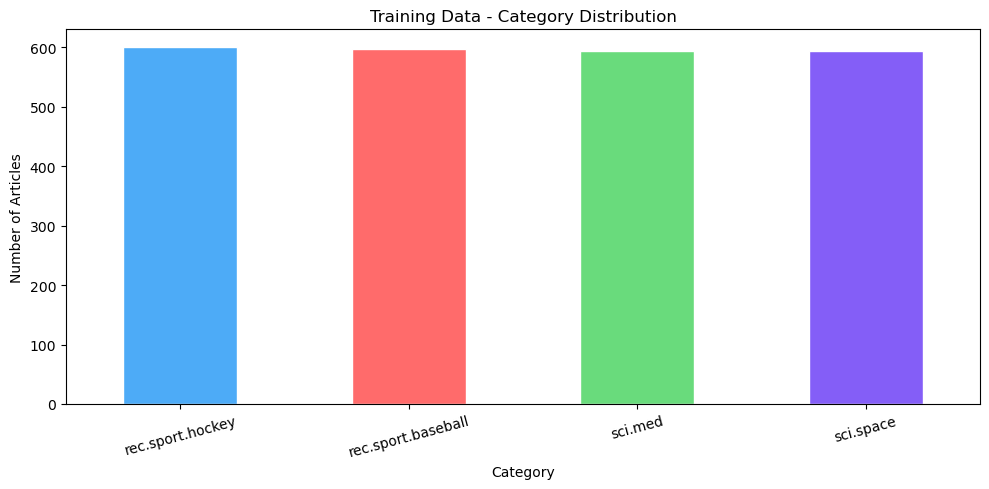

Category distribution chart saved!


In [4]:
# Create DataFrames for train and test
train_df = pd.DataFrame({
    'text'  : train_raw.data,
    'label' : train_raw.target,
    'category': [train_raw.target_names[t] for t in train_raw.target]
})

test_df = pd.DataFrame({
    'text'  : test_raw.data,
    'label' : test_raw.target,
    'category': [test_raw.target_names[t] for t in test_raw.target]
})

print("Training Data Distribution:")
print(train_df['category'].value_counts())

# Plot category distribution
plt.figure(figsize=(10, 5))
train_df['category'].value_counts().plot(
    kind='bar',
    color=['#4dabf7', '#ff6b6b', '#69db7c', '#845ef7'],
    edgecolor='white'
)
plt.title('Training Data - Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Category distribution chart saved!")

In [6]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full text preprocessing pipeline:
    1. Lowercase conversion
    2. Remove special characters and numbers
    3. Tokenization
    4. Remove stopwords
    5. Lemmatization
    """
    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Remove special characters, numbers, and extra spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 3: Tokenize - split text into individual words
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords (common words like 'the', 'is', 'at')
    tokens = [word for word in tokens if word not in stop_words]

    # Step 5: Lemmatize - convert words to base form
    # e.g. "running" -> "run", "better" -> "good"
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back to string
    return ' '.join(tokens)

# Apply preprocessing to all texts
print("Preprocessing text data...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

print("Text preprocessing complete!")
print("\nOriginal text sample:")
print(train_df['text'].iloc[0][:200])
print("\nCleaned text sample:")
print(train_df['clean_text'].iloc[0][:200])

Preprocessing text data...
Text preprocessing complete!

Original text sample:

A freeze dried Tootsie Roll (tm).  The actual taste sensation was like nothing
you will ever willingly experience.  The amazing thing was that we ate a second
one, and a third and ....

I doubt that 

Cleaned text sample:
freeze dried tootsie roll tm actual taste sensation like nothing ever willingly experience amazing thing ate second one third doubt actually flew mission im certain bad thing gastrointestinal tract co


In [7]:
# Convert text to numerical representation using TF-IDF
# TF-IDF = Term Frequency - Inverse Document Frequency
# Gives higher weight to words that are unique to a document

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,     # Use top 5000 most important words
    min_df=2,              # Ignore words appearing in less than 2 documents
    max_df=0.95,           # Ignore words appearing in more than 95% of documents
    ngram_range=(1, 2)     # Use both unigrams and bigrams
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['clean_text'])
X_test_tfidf  = tfidf_vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_test  = test_df['label']

print("TF-IDF Vectorization complete!")
print(f"\nTraining matrix shape : {X_train_tfidf.shape}")
print(f"Testing matrix shape  : {X_test_tfidf.shape}")
print(f"\nTop 20 most important words:")
feature_names = tfidf_vectorizer.get_feature_names_out()
print(feature_names[:20])

TF-IDF Vectorization complete!

Training matrix shape : (2384, 5000)
Testing matrix shape  : (1586, 5000)

Top 20 most important words:
['aa' 'aaa' 'aaron' 'ab' 'abc' 'abc coverage' 'ability' 'able' 'able get'
 'abort' 'absolute' 'absolutely' 'abstract' 'absurd' 'ac' 'academic'
 'acceleration' 'accept' 'acceptable' 'accepted']


In [8]:
# Define models to train and compare
models = {
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=1.0)
}

# Dictionary to store results
results = {}

print("Training models...\n")
print("-" * 60)

for model_name, model in models.items():

    # Train the model
    model.fit(X_train_tfidf, y_train)

    # Make predictions
    y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    f1        = f1_score(y_test, y_pred, average='weighted')

    # Store results
    results[model_name] = {
        'Accuracy'    : round(accuracy, 4),
        'Precision'   : round(precision, 4),
        'Recall'      : round(recall, 4),
        'F1 Score'    : round(f1, 4),
        'Predictions' : y_pred,
        'Model'       : model
    }

    print(f"{model_name}:")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print("-" * 60)

Training models...

------------------------------------------------------------
Naive Bayes:
  Accuracy  : 0.8789
  Precision : 0.8816
  Recall    : 0.8789
  F1 Score  : 0.8793
------------------------------------------------------------
Logistic Regression:
  Accuracy  : 0.8676
  Precision : 0.8687
  Recall    : 0.8676
  F1 Score  : 0.8679
------------------------------------------------------------


In [9]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [results[m]['Accuracy']  for m in results],
    'Precision': [results[m]['Precision'] for m in results],
    'Recall'   : [results[m]['Recall']    for m in results],
    'F1 Score' : [results[m]['F1 Score']  for m in results]
})

print("Model Comparison Table:")
print(comparison_df.to_string(index=False))

# Find best model
best_model = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']
best_f1    = comparison_df['F1 Score'].max()

print(f"\n🏆 Best Model  : {best_model}")
print(f"   Best F1 Score: {best_f1:.4f}")

Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1 Score
        Naive Bayes    0.8789     0.8816  0.8789    0.8793
Logistic Regression    0.8676     0.8687  0.8676    0.8679

🏆 Best Model  : Naive Bayes
   Best F1 Score: 0.8793


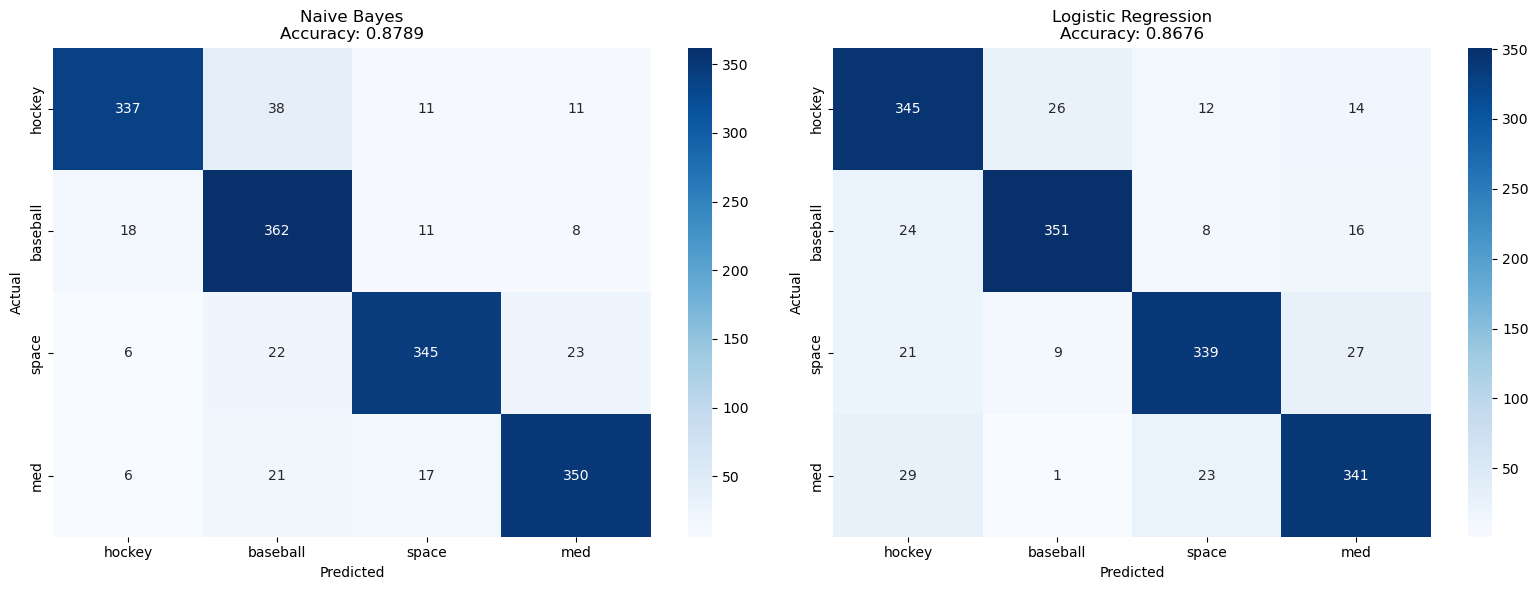

Confusion matrix saved as 'nlp_confusion_matrix.png'


In [10]:
# Plot confusion matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
category_names = [c.split('.')[-1] for c in categories]   # Short names

for idx, (model_name, model_results) in enumerate(results.items()):
    cm = confusion_matrix(y_test, model_results['Predictions'])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=category_names,
        yticklabels=category_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{model_name}\nAccuracy: {model_results["Accuracy"]:.4f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('nlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'nlp_confusion_matrix.png'")

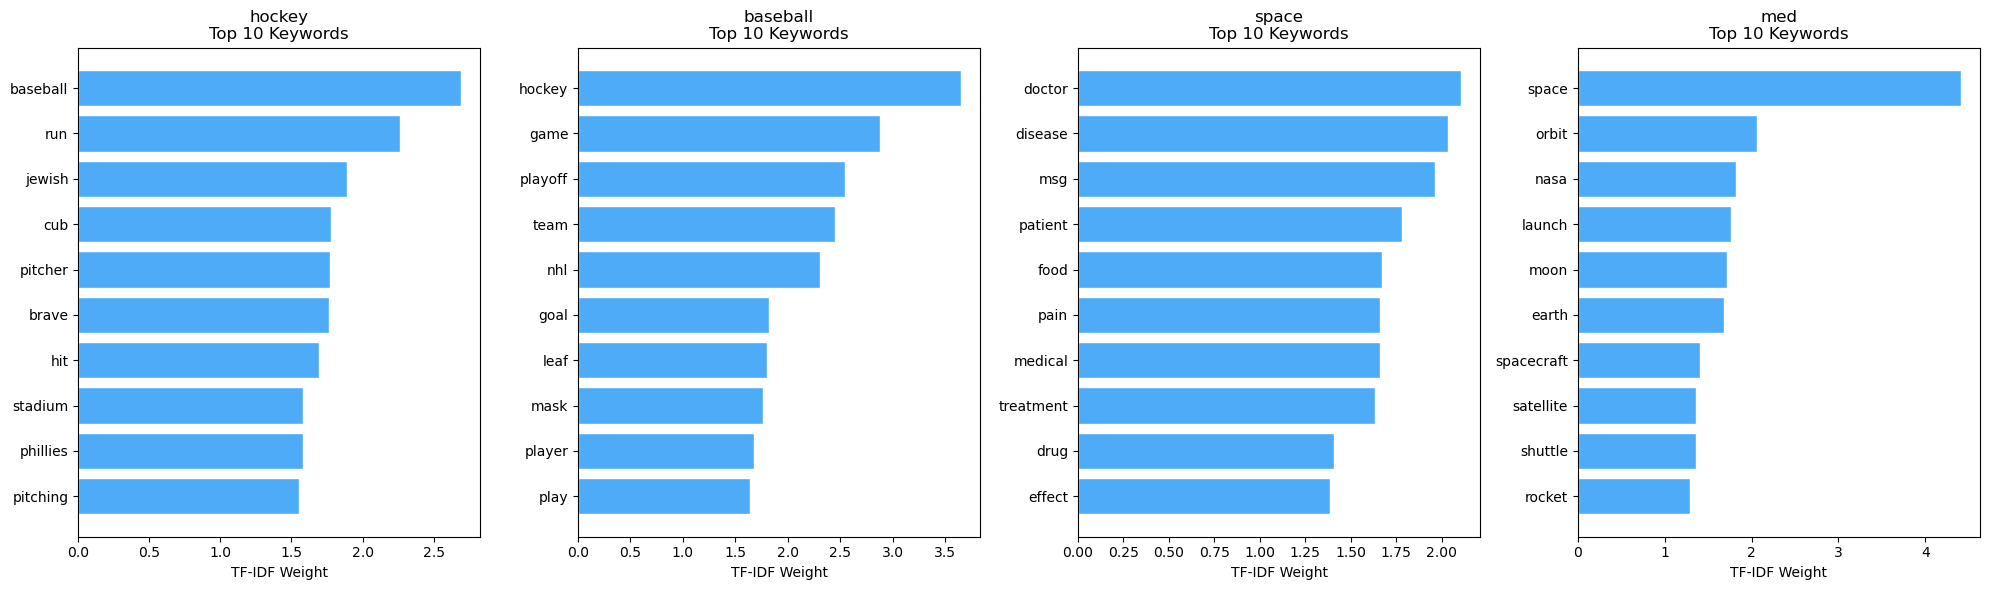

Top keywords chart saved as 'top_keywords.png'


In [11]:
# Show top keywords for each category (Logistic Regression)
lr_model    = results['Logistic Regression']['Model']
top_n       = 10

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for idx, (category, ax) in enumerate(zip(categories, axes)):
    # Get feature weights for this category
    feature_weights = lr_model.coef_[idx]

    # Get top N features
    top_indices  = np.argsort(feature_weights)[-top_n:]
    top_features = [feature_names[i] for i in top_indices]
    top_weights  = feature_weights[top_indices]

    # Plot horizontal bar chart
    ax.barh(top_features, top_weights, color='#4dabf7', edgecolor='white')
    ax.set_title(f'{category.split(".")[-1]}\nTop {top_n} Keywords')
    ax.set_xlabel('TF-IDF Weight')

plt.tight_layout()
plt.savefig('top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top keywords chart saved as 'top_keywords.png'")

In [13]:
# Detailed classification report for best model
print("=" * 60)
print(f"  DETAILED REPORT - {best_model}")
print("=" * 60)
print(classification_report(
    y_test,
    results[best_model]['Predictions'],
    target_names=category_names
))

  DETAILED REPORT - Naive Bayes
              precision    recall  f1-score   support

      hockey       0.92      0.85      0.88       397
    baseball       0.82      0.91      0.86       399
       space       0.90      0.87      0.88       396
         med       0.89      0.89      0.89       394

    accuracy                           0.88      1586
   macro avg       0.88      0.88      0.88      1586
weighted avg       0.88      0.88      0.88      1586



In [12]:
# Test the best model with custom text samples
def predict_category(text, model_name='Logistic Regression'):
    """
    Predict category of a given text using trained model
    """
    # Preprocess the input text
    clean  = preprocess_text(text)

    # Convert to TF-IDF vector
    vector = tfidf_vectorizer.transform([clean])

    # Predict
    pred   = results[model_name]['Model'].predict(vector)[0]
    return categories[pred].split('.')[-1]

# Test with sample texts
test_texts = [
    "The hockey team scored three goals in the final period to win the championship",
    "NASA launched a new rocket to explore the surface of Mars",
    "Doctors recommend taking vitamins to boost immune system health",
    "The baseball pitcher threw a perfect game against the rival team"
]

print("Custom Text Predictions:")
print("-" * 60)
for text in test_texts:
    prediction = predict_category(text)
    print(f"Text      : {text[:60]}...")
    print(f"Predicted : {prediction}")
    print("-" * 60)

Custom Text Predictions:
------------------------------------------------------------
Text      : The hockey team scored three goals in the final period to wi...
Predicted : baseball
------------------------------------------------------------
Text      : NASA launched a new rocket to explore the surface of Mars...
Predicted : med
------------------------------------------------------------
Text      : Doctors recommend taking vitamins to boost immune system hea...
Predicted : space
------------------------------------------------------------
Text      : The baseball pitcher threw a perfect game against the rival ...
Predicted : hockey
------------------------------------------------------------


In [13]:
print("=" * 60)
print("  TASK 2 - NLP TEXT CLASSIFICATION - SUMMARY")
print("=" * 60)
print(f"\n  Dataset         : 20 Newsgroups (4 categories)")
print(f"  Training Set    : {len(train_df)} articles")
print(f"  Testing Set     : {len(test_df)} articles")
print(f"  Vocabulary Size : {X_train_tfidf.shape[1]} features")
print(f"\n  Model Performance:")
print(comparison_df.to_string(index=False))
print(f"\n  Best Model      : {best_model}")
print(f"  Best F1 Score   : {best_f1:.4f}")
print(f"\n  Files Saved:")
print(f"    - category_distribution.png")
print(f"    - nlp_confusion_matrix.png")
print(f"    - top_keywords.png")
print("=" * 60)

  TASK 2 - NLP TEXT CLASSIFICATION - SUMMARY

  Dataset         : 20 Newsgroups (4 categories)
  Training Set    : 2384 articles
  Testing Set     : 1586 articles
  Vocabulary Size : 5000 features

  Model Performance:
              Model  Accuracy  Precision  Recall  F1 Score
        Naive Bayes    0.8789     0.8816  0.8789    0.8793
Logistic Regression    0.8676     0.8687  0.8676    0.8679

  Best Model      : Naive Bayes
  Best F1 Score   : 0.8793

  Files Saved:
    - category_distribution.png
    - nlp_confusion_matrix.png
    - top_keywords.png
